# 🧠 Model-Agnostic Task Complexity Estimator
### Method 1: Structural Feature Score — No LLM Inference Required

---

**Framework:** Composite weighted score over 5 orthogonal feature dimensions extracted from raw task text using classical NLP.

$$C(q) = w_S \cdot S + w_R \cdot R + w_T \cdot T + w_D \cdot D + w_{TT} \cdot TT \quad \in [0, 1]$$

| Layer | Dimension | Description |
|-------|-----------|-------------|
| L1 | **S** — Surface Features | Token count, lexical diversity (MATTR), NER density |
| L2 | **R** — Reasoning Depth | Bloom level, syntactic tree depth, multi-hop, negation, conditionals |
| L3 | **T** — Tool Dependency | Number of distinct tool/API calls needed |
| L4 | **D** — Domain Skills | Domain breadth, temporal reasoning |
| L5 | **TT** — Task Type | Generative > Reasoning > Alt-choice > Single > Decision |

**Key principle:** Zero LLM calls. Every feature is derived from deterministic NLP signals.

## Cell 0 — Install Dependencies

In [1]:
# Run once — restart kernel after this cell completes
import subprocess, sys

packages = ["spacy", "textstat", "scipy", "numpy", "pandas", "matplotlib", "seaborn"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# Download spaCy model with parser + NER
subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_md", "--quiet"])
print("✅ All dependencies installed.")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
✅ All dependencies installed.


## Cell 1 — Global Imports & spaCy Pipeline

In [2]:
from __future__ import annotations

import re
import math
import warnings
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import spacy
import textstat

warnings.filterwarnings("ignore")

# ── Load spaCy with ALL components needed across all layers ─────────────────
# We load once here at module level; downstream classes reuse this singleton.
_NLP = spacy.load("en_core_web_md")   # includes: tagger, parser, NER, vectors

print(f"✅ spaCy pipeline: {_NLP.pipe_names}")
print(f"✅ Model: en_core_web_md  |  Vocab: {len(_NLP.vocab):,} tokens")

✅ spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
✅ Model: en_core_web_md  |  Vocab: 764 tokens


## Cell 2 — Helper Utilities

In [3]:
def clamp(value: float, lo: float = 0.0, hi: float = 1.0) -> float:
    """Clamp a value to [lo, hi]."""
    return max(lo, min(hi, value))


def min_max_scale(value: float, lo: float, hi: float) -> float:
    """Map value from [lo, hi] → [0, 1].  Saturates at boundaries."""
    if hi == lo:
        return 0.0
    return clamp((value - lo) / (hi - lo))


def _tree_depth(token: spacy.tokens.Token) -> int:
    """Recursively compute depth of a token in the dependency tree."""
    if list(token.children):
        return 1 + max(_tree_depth(child) for child in token.children)
    return 1


def get_doc(text: str) -> spacy.tokens.Doc:
    """Process text through the global spaCy pipeline and return Doc."""
    return _NLP(text)


print("✅ Utility functions defined.")

✅ Utility functions defined.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 0 — Imports & Config
# ─────────────────────────────────────────────────────────────────────────────

import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

DATA_PATHS: Dict[str, Path] = {
    'gaia'     : Path('../datasets/processed/gaia.parquet'),
    'aime'     : Path('../datasets/processed/aime.parquet'),
    'mmlu_pro' : Path('../datasets/processed/mmlu_pro.parquet'),
    'musique'  : Path('../datasets/processed/musique.parquet'),
    'swe_bench' : Path('../datasets/processed/swe_bench.parquet'),
}

OUTPUT_DIR = Path('data/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')
print(f'   pandas  {pd.__version__}')
for name, path in DATA_PATHS.items():
    print(f'   {name:<10} → {path}')

✅ Imports OK
   pandas  3.0.1
   gaia       → ../datasets/processed/gaia.parquet
   aime       → ../datasets/processed/aime.parquet
   mmlu_pro   → ../datasets/processed/mmlu_pro.parquet
   musique    → ../datasets/processed/musique.parquet
   swe_bench  → ../datasets/processed/swe_bench.parquet


In [9]:

datasets: Dict[str, pd.DataFrame] = {}
for name, path in DATA_PATHS.items():
    df = pd.read_parquet(path)
    datasets[name] = df
    print(f"\n{'─' * 60}")
    print(f"📂 Dataset : {name.upper()}")
    print(f"   Path    : {path}")
    print(f"   Shape   : {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"   Columns : {list(df.columns)}")
    print(f"   Nulls   : {df.isnull().sum().sum():,} total missing values")
    # print(f"\n{df.head()}\n")

print(f"\n✅ Loaded {len(datasets)} datasets successfully")
sample= datasets['gaia']["query"][0]


────────────────────────────────────────────────────────────
📂 Dataset : GAIA
   Path    : ../datasets/processed/gaia.parquet
   Shape   : 165 rows × 7 cols
   Columns : ['id', 'query', 'answer', 'level', 'annotator_steps', 'annotator_tools', 'file_name']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : AIME
   Path    : ../datasets/processed/aime.parquet
   Shape   : 30 rows × 5 cols
   Columns : ['id', 'query', 'answer', 'year', 'solution']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : MMLU_PRO
   Path    : ../datasets/processed/mmlu_pro.parquet
   Shape   : 12,032 rows × 9 cols
   Columns : ['id', 'query', 'answer', 'answer_index', 'options', 'category', 'cot_content', 'src', 'cot_length']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : MUSIQUE
   Path    : ../datasets/processed/musique.parquet
   

## Cell 3 — L1: Surface Features (S)

**Captures:** lexical volume, vocabulary richness, and named-entity density.  
**Features:**
- `token_count` → raw word count  
- `ner_density` → entity tokens / total tokens  
- `mattr` → Moving-Average Type-Token Ratio (window=25); length-independent lexical diversity  

**Output S ∈ [0, 1]:** weighted combination, normalised against empirically reasonable query bounds.

In [11]:
class SurfaceFeatures:
    """
    L1 — Surface Features.

    Computes three length/richness signals from raw query text without any
    model inference:
      - token_count   : raw word count
      - ner_density   : fraction of tokens that are named entities
      - mattr         : Moving-Average Type-Token Ratio (window=25)

    These are combined into a single score S ∈ [0, 1].
    """

    # Normalisation bounds (empirically set for typical LLM benchmark queries)
    _TC_LO, _TC_HI   = 5,   150   # token count range
    _NER_LO, _NER_HI = 0.0, 0.25  # NER density range
    _MATTR_LO        = 0.2        # below this → very repetitive text
    _MATTR_HI        = 1.0

    # Sub-feature weights (must sum to 1.0)
    _W_TC    = 0.50
    _W_NER   = 0.30
    _W_MATTR = 0.20

    def __init__(self, text: str, doc: Optional[spacy.tokens.Doc] = None):
        self.text = text
        self.doc  = doc if doc is not None else get_doc(text)

    # ── Private sub-features ─────────────────────────────────────────────────

    def _token_count(self) -> int:
        """Count non-punctuation, non-whitespace tokens."""
        return sum(1 for t in self.doc if not t.is_punct and not t.is_space)

    def _ner_density(self) -> float:
        """Fraction of tokens that belong to a named entity span."""
        total = max(len(self.doc), 1)
        entity_token_count = sum(len(ent) for ent in self.doc.ents)
        return round(entity_token_count / total, 4)

    def _mattr(self, window: int = 25) -> float:
        """
        Moving-Average Type-Token Ratio.
        Slides a fixed-length window across all tokens, computes TTR at each
        position, then returns the mean.  Length-independent unlike raw TTR.
        Falls back to plain TTR when text is shorter than the window.
        """
        tokens = [t.lower_ for t in self.doc if not t.is_punct and not t.is_space]
        n = len(tokens)
        if n == 0:
            return 0.0
        if n <= window:
            return round(len(set(tokens)) / n, 4)
        ttr_scores = [
            len(set(tokens[i : i + window])) / window
            for i in range(n - window + 1)
        ]
        return round(sum(ttr_scores) / len(ttr_scores), 4)

    # ── Public API ───────────────────────────────────────────────────────────

    def raw_features(self) -> dict:
        return {
            "token_count": self._token_count(),
            "ner_density": self._ner_density(),
            "mattr":       self._mattr(),
        }

    def score(self) -> Tuple[float, dict]:
        """
        Returns (S, raw_features).
        S is the normalised surface complexity ∈ [0, 1].
        """
        raw = self.raw_features()

        s_tc    = min_max_scale(raw["token_count"], self._TC_LO,    self._TC_HI)
        s_ner   = min_max_scale(raw["ner_density"], self._NER_LO,   self._NER_HI)
        s_mattr = min_max_scale(raw["mattr"],       self._MATTR_LO, self._MATTR_HI)

        S = self._W_TC * s_tc + self._W_NER * s_ner + self._W_MATTR * s_mattr
        return clamp(S), raw


# ── Quick sanity check ───────────────────────────────────────────────────────

_sf   = SurfaceFeatures(sample)
_S, _r = _sf.score()
print(f"Demo query : '{sample}'")
print(f"Raw        : {_r}")
print(f"S score    : {_S:.4f}")

Demo query : 'A paper about AI regulation that was originally submitted to arXiv.org in June 2022 shows a figure with three axes, where each axis has a label word at both ends. Which of these words is used to describe a type of society in a Physics and Society article submitted to arXiv.org on August 11, 2016?'
Raw        : {'token_count': 55, 'ner_density': 0.1864, 'mattr': 0.9097}
S score    : 0.5735


## Cell 4 — L2: Reasoning Depth (R)

**Captures:** cognitive demand, structural complexity, and discourse-level reasoning.

**Sub-features:**

| Sub-feature | Signal | Proxy |
|-------------|--------|-------|
| `bloom_level` | Cognitive verb tier (1–6) | Regex over Bloom's action verbs |
| `syntactic_depth` | Max dependency tree depth | spaCy parser subtree recursion |
| `multi_hop` | Cross-entity reasoning steps | Boolean: 2+ distinct entity chains |
| `negation_count` | Logical inversions | `neg` dependency arcs |
| `conditional_count` | Hypothetical/causal reasoning | Conditional conjunctions |
| `modifier_density` | Adjectival/adverbial qualifiers | amod + advmod arc density |

In [16]:
# ── Bloom's Taxonomy verb lexicon (levels 1–6, compiled once) ───────────────
_BLOOM_VERBS: Dict[int, List[str]] = {
    1: [  # Remember — surface recall
        "define","list","recall","name","identify","recognize","state","label",
        "match","select","locate","arrange","duplicate","memorize","repeat",
        "reproduce","copy","quote","order","record","relate","underline",
        "who is","when was","where is","what year","what is the capital",
    ],
    2: [  # Understand — interpretation, paraphrase
        "explain","describe","interpret","paraphrase","restate","translate",
        "clarify","elaborate","simplify","convert","classify","categorize",
        "sort","group","infer","predict","conclude from","anticipate",
        "extrapolate","summarize","abstract","generalize","outline",
        "illustrate","give an example","represent","compare","report",
        "review","discuss","indicate","rewrite","what is the difference",
    ],
    3: [  # Apply — procedural, computational tasks
        "apply","use","implement","execute","carry out","perform","administer",
        "operate","employ","utilize","solve","compute","calculate","estimate",
        "determine","find","derive the value","work out","demonstrate",
        "show how to","illustrate how","construct","build","produce","make",
        "prepare","complete","modify","develop a solution","simulate","run",
        "test","sketch","map","write a function","code","script",
    ],
    4: [  # Analyze — decompose, compare, attribute
        "analyze","analyse","differentiate","distinguish","discriminate",
        "separate","decompose","deconstruct","break down","parse","dissect",
        "organize","structure","integrate","diagram","correlate",
        "attribute","deduce","detect","examine","investigate",
        "compare and contrast","contrast","examine differences",
        "compare the trade-offs","trade-off","trade-offs",
        "what are the trade-offs","explain why","what causes","trace",
        "map the relationship","identify assumptions","identify biases",
        "debate","prioritize",
    ],
    5: [  # Evaluate — judge, critique, defend
        "evaluate","assess","judge","critique","criticize","review critically",
        "appraise","rate","rank","check","monitor","validate","verify","debug",
        "judge whether","measure","inspect","score","justify","defend",
        "argue for","argue against","support","refute","counter","recommend",
        "decide","choose between","determine the best","conclude",
        "is it better to","should we","which is more","what is the optimal",
    ],
    6: [  # Create — synthesize, design, prove
        "design","plan","devise","propose","formulate","architect","blueprint",
        "create","develop","generate","produce","invent","originate","pioneer",
        "compose","author","draft","synthesize","combine","assemble","compile",
        "derive","prove","demonstrate that","show that","formally show",
        "from first principles","from scratch","hypothesize","theorize",
        "conjecture","postulate","novel","new approach","new method",
        "original","come up with","propose a new","imagine a new",
    ],
}

# Pre-compile sorted patterns: longest phrases first to avoid partial matches
_BLOOM_PATTERNS: Dict[int, re.Pattern] = {
    lvl: re.compile(
        r"\b(?:" + "|".join(
            re.escape(v) for v in sorted(verbs, key=len, reverse=True)
        ) + r")\b",
        re.IGNORECASE,
    )
    for lvl, verbs in _BLOOM_VERBS.items()
}

# Conditional conjunctions indicating hypothetical / causal reasoning
_CONDITIONAL_TOKENS = frozenset([
    "if","unless","provided","assuming","given","suppose","suppose that",
    "in the event","whenever","only if","even if","as long as",
    "because","since","therefore","thus","hence","consequently",
    "as a result","due to","owing to","so that","in order to",
])


class ReasoningDepth:
    """
    L2 — Reasoning Depth.

    Measures *cognitive* and *structural* complexity via:
      - Bloom's taxonomy level (1–6)  →  what cognitive operation is demanded
      - Syntactic tree depth          →  structural embedding of clauses
      - Multi-hop indicator           →  does the query chain across entities/steps
      - Negation count                →  logical inversions
      - Conditional count             →  hypothetical / causal constructs
      - Modifier density              →  adjectival + adverbial qualifiers

    All sub-features are normalised and combined into R ∈ [0, 1].
    """

    # Sub-feature weights (must sum to 1.0)
    _W = {
        "bloom":     0.30,
        "syn_depth": 0.20,
        "multi_hop": 0.15,
        "negation":  0.10,
        "condition": 0.15,
        "modifier":  0.10,
    }

    def __init__(self, text: str, doc: Optional[spacy.tokens.Doc] = None):
        self.text = text
        self.doc  = doc if doc is not None else get_doc(text)

    # ── Sub-features ─────────────────────────────────────────────────────────

    def _bloom_level(self) -> int:
        """
        Return the *highest* Bloom level matched in the text (1–6, default 1).
        Longer phrases are matched first (pre-sorted in _BLOOM_PATTERNS).
        """
        best = 1
        for lvl in range(6, 0, -1):   # check highest level first
            if _BLOOM_PATTERNS[lvl].search(self.text):
                best = lvl
                break
        return best

    def _syntactic_depth(self) -> float:
        """
        Mean maximum dependency-tree depth over all sentences.
        Higher = more deeply embedded clause structure.
        """
        depths = []
        for sent in self.doc.sents:
            root = sent.root
            depths.append(_tree_depth(root))
        return round(float(np.mean(depths)) if depths else 0.0, 4)

    def _is_multi_hop(self) -> bool:
        """
        Heuristic: query is multi-hop if it contains ≥2 distinct named entities
        AND at least one relational / comparison token.
        """
        entity_types = {ent.label_ for ent in self.doc.ents}
        if len(entity_types) < 2:
            return False
        relational_tokens = {"and","between","both","versus","vs","compared",
                             "relate","link","connect","differ","same","than"}
        query_tokens = {t.lower_ for t in self.doc}
        return bool(query_tokens & relational_tokens)

    def _negation_count(self) -> int:
        """Count tokens with a `neg` dependency arc."""
        return sum(1 for t in self.doc if t.dep_ == "neg")

    def _conditional_count(self) -> int:
        """Count conditional/causal conjunctions using the pre-defined lexicon."""
        tokens_lower = {t.lower_ for t in self.doc}
        return len(tokens_lower & _CONDITIONAL_TOKENS)

    def _modifier_density(self) -> float:
        """
        Ratio of adjectival (amod) + adverbial (advmod) modifiers to total tokens.
        Denser modifiers → more constrained, nuanced query.
        """
        total = max(len(self.doc), 1)
        mods  = sum(1 for t in self.doc if t.dep_ in {"amod", "advmod"})
        return round(mods / total, 4)

    # ── Public API ───────────────────────────────────────────────────────────

    def raw_features(self) -> dict:
        return {
            "bloom_level":      self._bloom_level(),
            "syntactic_depth":  self._syntactic_depth(),
            "multi_hop":        int(self._is_multi_hop()),
            "negation_count":   self._negation_count(),
            "conditional_count":self._conditional_count(),
            "modifier_density": self._modifier_density(),
        }

    def score(self) -> Tuple[float, dict]:
        """
        Returns (R, raw_features).
        R is the normalised reasoning complexity ∈ [0, 1].
        """
        raw = self.raw_features()

        # Bloom: levels 1–6 → scale to [0,1]
        s_bloom    = (raw["bloom_level"] - 1) / 5.0
        # Syntactic depth: typical range [2, 15]
        s_depth    = min_max_scale(raw["syntactic_depth"], 2.0, 15.0)
        # Multi-hop: binary
        s_hop      = float(raw["multi_hop"])
        # Negation: 0–4 typical range
        s_neg      = min_max_scale(raw["negation_count"], 0, 4)
        # Conditionals: 0–5 typical range
        s_cond     = min_max_scale(raw["conditional_count"], 0, 5)
        # Modifier density: 0–0.25 typical range
        s_mod      = min_max_scale(raw["modifier_density"], 0.0, 0.25)

        W = self._W
        R = (W["bloom"]     * s_bloom  +
             W["syn_depth"] * s_depth  +
             W["multi_hop"] * s_hop    +
             W["negation"]  * s_neg    +
             W["condition"] * s_cond   +
             W["modifier"]  * s_mod)
        return clamp(R), raw


# ── Sanity check ────────────────────────────────────────────────────────────
_demo_r = "Analyze and compare the trade-offs between transformer and LSTM architectures for long-range dependency modelling."
_rd     = ReasoningDepth(sample)
_R, _rr = _rd.score()
print(f"Demo : '{sample[:70]}...'")
print(f"Raw  : {_rr}")
print(f"R    : {_R:.4f}")

Demo : 'A paper about AI regulation that was originally submitted to arXiv.org...'
Raw  : {'bloom_level': 2, 'syntactic_depth': 8.0, 'multi_hop': 1, 'negation_count': 0, 'conditional_count': 0, 'modifier_density': 0.0339}
R    : 0.3159


## Cell 5 — L3: Tool Dependency (T)

**Captures:** whether the task requires external tool calls, APIs, code execution, or system interaction — a strong proxy for agentic complexity.  

**Method:** Keyword / regex scan over a curated tool-signal lexicon, grouped into categories.  
T ∈ [0, 1] is proportional to the number of distinct tool categories triggered.

In [20]:
# ── Tool-signal lexicon grouped by category ──────────────────────────────────
_TOOL_SIGNALS: Dict[str, List[str]] = {
    "code_execution":  [
        "run","execute","compile","script","program","code","function",
        "algorithm","implement","debug","unit test","pytest","bash","terminal",
        "command line","cli","shell","subprocess","notebook","jupyter",
    ],
    "web_search":      [
        "search","browse","look up","find online","google","bing","retrieve",
        "latest","current","real-time","live","up-to-date","news",
        "fetch","scrape","crawl","url","website","webpage",".com",".org",".in",
    ],
    "file_io":         [
        "read file","write file","open file","save to","load from","csv","json",
        "excel","pdf","word doc","docx","txt","download","upload","import",
        "export","parse document","extract from","dataset",
    ],
    "api_call":        [
        "api","rest","graphql","endpoint","request","response","http","https",
        "curl","webhook","oauth","token","authenticate","authorize",
        "call service","microservice","grpc",
    ],
    "database":        [
        "database","sql","query","select","insert","update","delete","join",
        "table","schema","mongodb","postgres","mysql","sqlite","redis",
        "elasticsearch","nosql",
    ],
    "external_service": [
        "slack","email","calendar","send message","notify","alert",
        "github","jira","trello","confluence","zapier","ifttt",
        "gpt","llm","openai","anthropic","claude","gemini",
    ],
    "math_computation": [
        "calculate","compute","integral","derivative","matrix","solve equation",
        "eigenvalue","optimize","gradient","probability","statistics",
        "regression","fourier","laplace",
    ],
    "multimodal":      [
        "image","photo","picture","diagram","chart","graph","plot","video",
        "audio","speech","transcribe","ocr","caption","visualize",
    ],
}

# Compile each category into a single regex
_TOOL_PATTERNS: Dict[str, re.Pattern] = {
    cat: re.compile(
        r"\b(?:" + "|".join(re.escape(t) for t in sorted(terms, key=len, reverse=True)) + r")\b",
        re.IGNORECASE,
    )
    for cat, terms in _TOOL_SIGNALS.items()
}


class ToolDependency:
    """
    L3 — Tool Dependency.

    Identifies which external tool *categories* the task likely requires and
    returns a normalised score T ∈ [0, 1] based on the count of distinct
    categories triggered.

    Having 1 tool category → moderate complexity;  
    Having 4+ categories   → high agentic complexity (T → 1.0).
    """

    _MAX_CATS = 4   # saturation point

    def __init__(self, text: str):
        self.text = text

    def raw_features(self) -> dict:
        hits = {cat: bool(_TOOL_PATTERNS[cat].search(self.text))
                for cat in _TOOL_PATTERNS}
        return {
            "matched_categories": [c for c, v in hits.items() if v],
            "category_count":     sum(hits.values()),
            "category_flags":     hits,
        }

    def score(self) -> Tuple[float, dict]:
        """
        Returns (T, raw_features).  T ∈ [0, 1].
        T = min(category_count / MAX_CATS, 1.0)
        """
        raw = self.raw_features()
        T   = clamp(raw["category_count"] / self._MAX_CATS)
        return T, raw


# ── Sanity check ─────────────────────────────────────────────────────────────
_demo_t = "Search the web for the latest arxiv papers, download the PDFs and run a Python script to extract key contributions."
_td     = ToolDependency(sample)
_T, _rt = _td.score()
print(f"Demo : '{sample[:]}...'")
print(f"Raw  : categories={_rt['matched_categories']}, count={_rt['category_count']}")
print(f"T    : {_T:.4f}")

Demo : 'A paper about AI regulation that was originally submitted to arXiv.org in June 2022 shows a figure with three axes, where each axis has a label word at both ends. Which of these words is used to describe a type of society in a Physics and Society article submitted to arXiv.org on August 11, 2016?...'
Raw  : categories=['web_search'], count=1
T    : 0.2500


## Cell 6 — L4: Domain Skills (D)

**Captures:** breadth and depth of domain knowledge required.  

**Sub-features:**
- `domain_count` → how many distinct knowledge domains are referenced  
- `temporal_complexity` → presence of date arithmetic, historical context, or future prediction

D ∈ [0, 1] grows with multi-domain queries and temporal reasoning demands.

In [21]:
_DOMAIN_SIGNALS: Dict[str, List[str]] = {
    "mathematics":   [
        "theorem","proof","lemma","calculus","algebra","geometry","topology",
        "number theory","combinatorics","probability","statistics","integral",
        "derivative","polynomial","matrix","vector space","differential equation",
    ],
    "computer_science": [
        "algorithm","data structure","complexity","big-o","recursion","sorting",
        "graph","tree","dynamic programming","machine learning","neural network",
        "transformer","attention","gradient","backpropagation","compiler",
        "operating system","concurrency","parallelism","distributed","blockchain",
    ],
    "science":       [
        "physics","chemistry","biology","quantum","thermodynamics","genetics",
        "protein","molecule","atom","electron","cell","dna","rna","enzyme",
        "evolution","ecology","astronomy","relativity","nuclear",
    ],
    "medicine":      [
        "diagnosis","symptom","treatment","drug","clinical","patient",
        "surgery","pathology","pharmacology","dosage","side effect",
        "trial","prognosis","cancer","diabetes","blood pressure",
    ],
    "law":           [
        "statute","regulation","legal","law","court","jurisdiction",
        "precedent","contract","liability","intellectual property",
        "gdpr","compliance","patent","copyright","tort",
    ],
    "finance":       [
        "stock","bond","option","derivative","portfolio","hedge","equity",
        "valuation","balance sheet","income statement","cash flow","roi",
        "interest rate","inflation","gdp","monetary policy",
    ],
    "history_culture":[
        "war","empire","revolution","civilization","ancient","medieval",
        "renaissance","colonialism","culture","philosophy","religion",
        "mythology","archaeology","linguistics",
    ],
    "engineering":   [
        "circuit","electrical","mechanical","structural","thermal","fluid",
        "signal processing","control system","robotics","embedded",
        "fpga","microcontroller","antenna","semiconductor",
    ],
}

_DOMAIN_PATTERNS: Dict[str, re.Pattern] = {
    dom: re.compile(
        r"\b(?:" + "|".join(re.escape(k) for k in sorted(kw, key=len, reverse=True)) + r")\b",
        re.IGNORECASE,
    )
    for dom, kw in _DOMAIN_SIGNALS.items()
}

# Temporal complexity indicators
_TEMPORAL_SIGNALS = [
    re.compile(r"\b(\d{4}|\d{1,2}/\d{1,2}/\d{2,4})\b"),          # explicit dates
    re.compile(r"\b(before|after|since|until|during|between|by|\d+\s*(years?|months?|days?|decades?))\b", re.I),
    re.compile(r"\b(historical|future|predict|forecast|trend|evolve|timeline)\b", re.I),
    re.compile(r"\b(current|latest|recent|today|now|as of)\b", re.I),
]


class DomainSkills:
    """
    L4 — Domain Skills.

    Measures cross-domain breadth and temporal reasoning:
      - domain_count         : number of distinct knowledge domains hit
      - temporal_complexity  : number of distinct temporal signal patterns matched

    D ∈ [0, 1] saturates at 4+ domains or 3+ temporal signals.
    """

    _W_DOMAIN   = 0.65
    _W_TEMPORAL = 0.35
    _MAX_DOMAIN   = 4    # saturation point for domain count
    _MAX_TEMPORAL = 3    # saturation point for temporal signals

    def __init__(self, text: str):
        self.text = text

    def raw_features(self) -> dict:
        domains_hit  = {d for d, pat in _DOMAIN_PATTERNS.items() if pat.search(self.text)}
        temp_signals = sum(1 for pat in _TEMPORAL_SIGNALS if pat.search(self.text))
        return {
            "matched_domains":   sorted(domains_hit),
            "domain_count":      len(domains_hit),
            "temporal_signals":  temp_signals,
        }

    def score(self) -> Tuple[float, dict]:
        """Returns (D, raw_features).  D ∈ [0, 1]."""
        raw = self.raw_features()
        s_domain   = min_max_scale(raw["domain_count"],     0, self._MAX_DOMAIN)
        s_temporal = min_max_scale(raw["temporal_signals"], 0, self._MAX_TEMPORAL)
        D = self._W_DOMAIN * s_domain + self._W_TEMPORAL * s_temporal
        return clamp(D), raw


# ── Sanity check ─────────────────────────────────────────────────────────────
_demo_d = "Compare the historical evolution of quantum computing hardware since 2000 and predict the next decade's trajectory."
_ds     = DomainSkills(sample)
_D, _rd2 = _ds.score()
print(f"Demo    : '{sample[:70]}...'")
print(f"Domains : {_rd2['matched_domains']}  (count={_rd2['domain_count']})")
print(f"Temporal: {_rd2['temporal_signals']} signal(s)")
print(f"D       : {_D:.4f}")

Demo    : 'A paper about AI regulation that was originally submitted to arXiv.org...'
Domains : ['law', 'science']  (count=2)
Temporal: 1 signal(s)
D       : 0.4417


## Cell 7 — L5: Task Type (TT)

**Captures:** the structural *output* demanded by the task.  
Complexity inherent in the expected response format:

| Type | Score | Examples |
|------|-------|----------|
| Generative | 1.0 | Compose, write, design, create, generate |
| Reasoning | 0.8 | Prove, analyze, explain why, derive |
| Alt-choice | 0.5 | Which is better, compare options, select best |
| Single-answer | 0.3 | What year, who is, where is |
| Boolean/Decision | 0.15 | Is X true, yes/no, does X exist |

TT is the highest-scoring type matched in the query.

In [22]:
# Task type definitions: (name, score, trigger_patterns)
_TASK_TYPE_RULES: List[Tuple[str, float, re.Pattern]] = [
    (
        "generative", 1.0,
        re.compile(
            r"\b(write|compose|draft|generate|create|design|build|develop|produce"
            r"|author|invent|synthesize|formulate|devise|architect|plan a|propose a"
            r"|construct|make a|come up with)\b",
            re.I,
        ),
    ),
    (
        "reasoning", 0.8,
        re.compile(
            r"\b(prove|derive|show that|explain why|analyze|analyse|justify"
            r"|evaluate|assess|critique|reason|investigate|demonstrate that"
            r"|how does|why does|what causes|what leads to|infer|conclude)\b",
            re.I,
        ),
    ),
    (
        "alt_choice", 0.5,
        re.compile(
            r"\b(which is better|compare|choose between|select the best|best option"
            r"|trade-off|versus|vs\.?|alternatives|should i use|recommend|rank"
            r"|what would you prefer|which approach)\b",
            re.I,
        ),
    ),
    (
        "single_answer", 0.3,
        re.compile(
            r"\b(what is|who is|where is|when was|what year|how many|how much"
            r"|what was|name the|list the|define|what does .* mean|capital of)\b",
            re.I,
        ),
    ),
    (
        "boolean_decision", 0.15,
        re.compile(
            r"\b(is it|is there|are there|does .* exist|can .* be|is .* true"
            r"|do .* have|has .* ever|was .* ever|would .* work|is .* possible)\b",
            re.I,
        ),
    ),
]


class TaskType:
    """
    L5 — Task Type.

    Classifies the *structural output demanded* by the query and maps it to a
    complexity score TT ∈ [0, 1].  Evaluation follows a priority cascade:
    the first (highest-complexity) matching rule wins.

    Types, in descending order of complexity:
      generative (1.0) > reasoning (0.8) > alt_choice (0.5)
      > single_answer (0.3) > boolean_decision (0.15)
    """

    def __init__(self, text: str):
        self.text = text

    def raw_features(self) -> dict:
        matched = []
        for name, score, pattern in _TASK_TYPE_RULES:
            if pattern.search(self.text):
                matched.append({"type": name, "score": score})
        # Highest complexity type is the first in the sorted list
        best = matched[0] if matched else {"type": "unknown", "score": 0.2}
        return {
            "primary_type":  best["type"],
            "primary_score": best["score"],
            "all_matched":   matched,
        }

    def score(self) -> Tuple[float, dict]:
        """Returns (TT, raw_features).  TT ∈ [0, 1]."""
        raw = self.raw_features()
        return clamp(raw["primary_score"]), raw


# ── Sanity check ─────────────────────────────────────────────────────────────
for _q in [
    "Write a novel short story about AI consciousness.",
    "Analyze why LSTM vanishing gradient problem occurs.",
    "Which is better: PyTorch or TensorFlow for research?",
    "What year was Python first released?",
    "Is transformer architecture Turing complete?",
]:
    _tt = TaskType(_q)
    _TT, _rtt = _tt.score()
    print(f"[{_rtt['primary_type']:20s} | TT={_TT:.2f}]  '{_q[:55]}'")

[generative           | TT=1.00]  'Write a novel short story about AI consciousness.'
[reasoning            | TT=0.80]  'Analyze why LSTM vanishing gradient problem occurs.'
[alt_choice           | TT=0.50]  'Which is better: PyTorch or TensorFlow for research?'
[single_answer        | TT=0.30]  'What year was Python first released?'
[unknown              | TT=0.20]  'Is transformer architecture Turing complete?'


## Cell 8 — Composite Scorer: C(q)

Combines all 5 layers into the final complexity score:

$$C(q) = w_S \cdot S + w_R \cdot R + w_T \cdot T + w_D \cdot D + w_{TT} \cdot TT$$

Default weights are grounded in the professor's framework (Reasoning is the dominant signal).

In [ ]:
@dataclass
class ComplexityResult:
    """Full result container for one query."""
    query:          str
    C:              float           # final composite score ∈ [0,1]
    S:              float
    R:              float
    T:              float
    D:              float
    TT:             float
    raw_S:          dict = field(repr=False)
    raw_R:          dict = field(repr=False)
    raw_T:          dict = field(repr=False)
    raw_D:          dict = field(repr=False)
    raw_TT:         dict = field(repr=False)
    complexity_band: str = ""       # human-readable tier

    def __post_init__(self):
        if   self.C < 0.25:  self.complexity_band = "🟢 LOW"
        elif self.C < 0.50:  self.complexity_band = "🟡 MEDIUM"
        elif self.C < 0.75:  self.complexity_band = "🟠 HIGH"
        else:                self.complexity_band = "🔴 VERY HIGH"

    def summary(self) -> str:
        return (
            f"C={self.C:.3f} {self.complexity_band}  "
            f"[S={self.S:.2f} R={self.R:.2f} T={self.T:.2f} "
            f"D={self.D:.2f} TT={self.TT:.2f}]"
        )


class TaskComplexityEstimator:
    """
    Model-Agnostic Task Complexity Estimator.

    Computes  C(q) = w_S*S + w_R*R + w_T*T + w_D*D + w_TT*TT
    entirely from classical NLP features — zero LLM calls.

    Parameters
    ----------
    weights : dict, optional
        Custom weights for each dimension.  Must include keys
        'S', 'R', 'T', 'D', 'TT'.  Automatically renormalized to sum=1.
    """

    # Default weights — calibrated so reasoning is the dominant signal,
    # followed by task type, then surface / tool / domain.
    _DEFAULT_WEIGHTS = {
        "S":  0.15,   # Surface Features
        "R":  0.35=,   # Reasoning Depth  
        "T":  0.20,   # Tool Dependency
        "D":  0.15,   # Domain Skills
        "TT": 0.15,   # Task Type
    }

    def __init__(self, weights: Optional[Dict[str, float]] = None):
        raw_w = weights or self._DEFAULT_WEIGHTS
        total = sum(raw_w.values())
        self.weights = {k: v / total for k, v in raw_w.items()}  # normalise

    def score(self, query: str) -> ComplexityResult:
        """Estimate the complexity of a single query string."""
        # Parse once, share the Doc across L1 and L2
        doc = get_doc(query)

        S,  raw_S  = SurfaceFeatures(query, doc=doc).score()
        R,  raw_R  = ReasoningDepth(query,  doc=doc).score()
        T,  raw_T  = ToolDependency(query).score()
        D,  raw_D  = DomainSkills(query).score()
        TT, raw_TT = TaskType(query).score()

        w = self.weights
        C = clamp(w["S"]*S + w["R"]*R + w["T"]*T + w["D"]*D + w["TT"]*TT)

        return ComplexityResult(
            query=query, C=C,
            S=S, R=R, T=T, D=D, TT=TT,
            raw_S=raw_S, raw_R=raw_R, raw_T=raw_T,
            raw_D=raw_D, raw_TT=raw_TT,
        )

    def score_batch(self, queries: List[str]) -> pd.DataFrame:
        """Score a list of queries and return a tidy DataFrame."""
        records = []
        for q in queries:
            r = self.score(q)
            records.append({
                "query":            q[:80] + ("..." if len(q) > 80 else ""),
                "C":                round(r.C,  3),
                "S":                round(r.S,  3),
                "R":                round(r.R,  3),
                "T":                round(r.T,  3),
                "D":                round(r.D,  3),
                "TT":               round(r.TT, 3),
                "band":             r.complexity_band,
                "task_type":        r.raw_TT["primary_type"],
                "bloom_level":      r.raw_R["bloom_level"],
                "tool_categories":  ", ".join(r.raw_T["matched_categories"]) or "none",
                "domains":          ", ".join(r.raw_D["matched_domains"]) or "none",
            })
        return pd.DataFrame(records)


# ── Instantiate global estimator ─────────────────────────────────────────────
estimator = TaskComplexityEstimator()
print(f"✅ Estimator ready.  Effective weights: {estimator.weights}")

✅ Estimator ready.  Effective weights: {'S': 0.15, 'R': 0.3, 'T': 0.2, 'D': 0.2, 'TT': 0.15}


## Cell 9 — Benchmark Task Suite

We test on a diverse set of tasks spanning different benchmarks mentioned in the professor's discussion:
- **Simple factoid** (GSM8K-easy, MMLU recall)
- **Math reasoning** (GSM8K-hard, MATH competition)
- **Code / SWE** (SWE-bench style)
- **Multi-hop QA** (HotpotQA, MuSiQue)
- **Agentic / Tool-use** (GAIA, ToolBench)
- **Scientific reasoning** (GPQA)

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Score Task Complexity for All Datasets
# ─────────────────────────────────────────────────────────────────────────────

QUERY_COL_MAP: Dict[str, str] = {
    "gaia"      : "query",
    "aime"      : "query",
    "mmlu_pro"  : "query",
    "musique"   : "query",
    "swe_bench" : "query",
}

scored_datasets: Dict[str, pd.DataFrame] = {}

for name, df in datasets.items():
    query_col = QUERY_COL_MAP.get(name, "query")

    # ── Validate the query column exists ────────────────────────────────────
    if query_col not in df.columns:
        available = [c for c in df.columns if "query" in c.lower() or "question" in c.lower()]
        raise KeyError(
            f"[{name}] Expected column '{query_col}' not found. "
            f"Possible candidates: {available or list(df.columns)}"
        )

    queries: List[str] = (
        df[query_col]
        .fillna("")          # guard against NaN rows
        .astype(str)
        .tolist()
    )

    print(f"\n{'─' * 60}")
    print(f"⚙️  Scoring  : {name.upper()}  ({len(queries):,} queries)")

    # ── Batch score ──────────────────────────────────────────────────────────
    scored_df: pd.DataFrame = estimator.score_batch(queries)

    # ── Merge complexity columns back onto the original DataFrame ────────────
    complexity_cols = ["C", "S", "R", "T", "D", "TT",
                       "band", "task_type", "bloom_level",
                       "tool_categories", "domains"]

    # Reset indices to guarantee alignment before concat
    merged_df = pd.concat(
        [df.reset_index(drop=True), scored_df[complexity_cols].reset_index(drop=True)],
        axis=1,
    )

    scored_datasets[name] = merged_df

    # ── Per-dataset summary ──────────────────────────────────────────────────
    band_counts = merged_df["band"].value_counts()
    print(f"   Rows scored : {len(merged_df):,}")
    print(f"   Avg C score : {merged_df['C'].mean():.3f}  "
          f"(min={merged_df['C'].min():.3f}, max={merged_df['C'].max():.3f})")
    print(f"   Band distribution:")
    for band, count in band_counts.items():
        pct = count / len(merged_df) * 100
        print(f"     {band:<20} {count:>5,}  ({pct:5.1f}%)")

    # ── Save individual file ─────────────────────────────────────────────────
    out_path = OUTPUT_DIR / f"{name}_complexity.parquet"
    merged_df.to_parquet(out_path, index=False)
    print(f"   💾 Saved → {out_path}")

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Cross-Dataset Summary Table
# ─────────────────────────────────────────────────────────────────────────────

summary_rows = []
for name, df in scored_datasets.items():
    summary_rows.append({
        "dataset"    : name,
        "n_queries"  : len(df),
        "mean_C"     : round(df["C"].mean(),  3),
        "mean_S"     : round(df["S"].mean(),  3),
        "mean_R"     : round(df["R"].mean(),  3),
        "mean_T"     : round(df["T"].mean(),  3),
        "mean_D"     : round(df["D"].mean(),  3),
        "mean_TT"    : round(df["TT"].mean(), 3),
        "pct_LOW"    : round((df["band"].str.contains("LOW")   & ~df["band"].str.contains("VERY")).sum() / len(df) * 100, 1),
        "pct_MEDIUM" : round( df["band"].str.contains("MEDIUM").sum() / len(df) * 100, 1),
        "pct_HIGH"   : round((df["band"].str.contains("HIGH")  & ~df["band"].str.contains("VERY")).sum() / len(df) * 100, 1),
        "pct_VHIGH"  : round( df["band"].str.contains("VERY HIGH").sum() / len(df) * 100, 1),
    })

summary_df = pd.DataFrame(summary_rows).set_index("dataset")

summary_path = OUTPUT_DIR / "all_datasets_complexity_summary.parquet"
summary_df.to_parquet(summary_path)

print("\n" + "═" * 60)
print("📊 CROSS-DATASET COMPLEXITY SUMMARY")
print("═" * 60)
print(summary_df.to_string())
print(f"\n✅ All files saved to  → {OUTPUT_DIR}/")
print(f"   Summary table saved → {summary_path}")


────────────────────────────────────────────────────────────
⚙️  Scoring  : GAIA  (165 queries)
   Rows scored : 165
   Avg C score : 0.250  (min=0.117, max=0.483)
   Band distribution:
     🟢 LOW                   97  ( 58.8%)
     🟡 MEDIUM                68  ( 41.2%)
   💾 Saved → data/processed/gaia_complexity.parquet

────────────────────────────────────────────────────────────
⚙️  Scoring  : AIME  (30 queries)
   Rows scored : 30
   Avg C score : 0.228  (min=0.155, max=0.365)
   Band distribution:
     🟢 LOW                   22  ( 73.3%)
     🟡 MEDIUM                 8  ( 26.7%)
   💾 Saved → data/processed/aime_complexity.parquet

────────────────────────────────────────────────────────────
⚙️  Scoring  : MMLU_PRO  (12,032 queries)
   Rows scored : 12,032
   Avg C score : 0.193  (min=0.053, max=0.647)
   Band distribution:
     🟢 LOW                9,120  ( 75.8%)
     🟡 MEDIUM             2,839  ( 23.6%)
     🟠 HIGH                  73  (  0.6%)
   💾 Saved → data/processed/mmlu_

In [24]:
BENCHMARK_TASKS = [
    # ── GSM8K / MATH — varying complexity ─────────────────────────────────────
    ("GSM8K-Easy",     "What is 25 + 37?"),
    ("GSM8K-Medium",   "A train travels 60 km/h for 2.5 hours and then 80 km/h for 1.5 hours. What is the total distance?"),
    ("GSM8K-Hard",     "A store sells apples for $1.20 each and offers a 15% discount for purchases of 10 or more. If Anna buys 12 apples and Ben buys 7 apples, how much more does Ben pay per apple than Anna?"),
    ("MATH-Competition","Prove that for all positive integers n, the sum 1² + 2² + ... + n² = n(n+1)(2n+1)/6 using mathematical induction."),

    # ── MMLU — factoid recall ─────────────────────────────────────────────────
    ("MMLU-Recall",    "What is the capital of France?"),
    ("MMLU-Understand","Explain the difference between supervised and unsupervised learning in machine learning."),
    ("MMLU-Apply",     "Calculate the time complexity of merge sort and explain why it is O(n log n)."),

    # ── Multi-hop QA ──────────────────────────────────────────────────────────
    ("HotpotQA-Simple","Who is the CEO of OpenAI?"),
    ("HotpotQA-Multi",  "Compare the founding philosophies of OpenAI and Anthropic and analyze how those philosophies influenced their respective approaches to AI safety."),
    ("MuSiQue-Hard",    "The author of the Transformer paper was affiliated with which institution, and what other major NLP architecture did that institution's research group produce before 2015?"),

    # ── SWE-bench / Code ──────────────────────────────────────────────────────
    ("SWE-Simple",     "Write a Python function that reverses a string."),
    ("SWE-Medium",     "Implement a thread-safe LRU cache in Python with O(1) get and put operations, using only the standard library."),
    ("SWE-Hard",        "Analyze the GitHub issue: 'Concurrent writes to the SQLite WAL cause silent data corruption under heavy load.' Identify the root cause, propose a fix with code, and write regression tests."),

    # ── GAIA / Agentic ────────────────────────────────────────────────────────
    ("GAIA-Simple",    "Search the web for the latest release version of Python and return it."),
    ("GAIA-Complex",   "Search arxiv for the three most-cited papers on RLHF published in 2023, download their PDFs, extract the key contributions into a CSV file, and compute a citation-weighted average complexity score."),

    # ── GPQA — PhD-level science ──────────────────────────────────────────────
    ("GPQA-Science",   "Derive the Schrödinger equation from first principles using the de Broglie hypothesis and the concept of a matter wave, then explain how the Copenhagen interpretation resolves the measurement problem."),

    # ── Decision / Boolean ────────────────────────────────────────────────────
    ("Decision",       "Is it better to use attention mechanisms or convolutional layers for sequence modelling tasks with long-range dependencies?"),
    ("Boolean",        "Does the P vs NP problem have a known solution as of 2024?"),
]

queries = [q for _, q in BENCHMARK_TASKS]
labels  = [l for l, _ in BENCHMARK_TASKS]

print(f"✅ {len(BENCHMARK_TASKS)} benchmark tasks loaded.")

✅ 18 benchmark tasks loaded.


## Cell 10 — Run the Estimator & Inspect Results

In [25]:
df = estimator.score_batch(queries)
df.insert(0, "label", labels)
df = df.sort_values("C", ascending=False).reset_index(drop=True)

# Display full table
pd.set_option("display.max_colwidth", 55)
pd.set_option("display.float_format", "{:.3f}".format)
print("\n━━━ Task Complexity Scores ━━━━━━━━━━━━━━━━━━━━━━━━━")
display(df[["label","C","S","R","T","D","TT","band","task_type","bloom_level"]])


━━━ Task Complexity Scores ━━━━━━━━━━━━━━━━━━━━━━━━━


,label,C,S,R,T,D,TT,band,task_type,bloom_level
0,SWE-Hard,0.540,0.393,0.375,1.000,0.000,1.000,🟠 HIGH,generative,6
1,GAIA-Complex,0.465,0.407,0.520,0.750,0.279,0.200,🟡 MEDIUM,unknown,5
2,MuSiQue-Hard,0.456,0.386,0.540,0.000,0.396,1.000,🟡 MEDIUM,generative,6
3,GPQA-Science,0.383,0.369,0.594,0.000,0.000,0.800,🟡 MEDIUM,reasoning,6
4,HotpotQA-Multi,0.317,0.284,0.299,0.250,0.000,0.800,🟡 MEDIUM,reasoning,4
5,MMLU-Apply,0.317,0.234,0.250,0.250,0.163,0.800,🟡 MEDIUM,reasoning,4
6,MATH-Competition,0.296,0.279,0.383,0.000,0.000,0.800,🟡 MEDIUM,reasoning,6
7,SWE-Medium,0.262,0.353,0.368,0.250,0.000,0.200,🟡 MEDIUM,unknown,3
8,Boolean,0.261,0.485,0.225,0.000,0.233,0.500,🟡 MEDIUM,alt_choice,1
9,SWE-Simple,0.243,0.179,0.046,0.250,0.000,1.000,🟢 LOW,generative,1


## Cell 11 — Visualization 1: Score Bar Chart

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/complexity_bar.png'

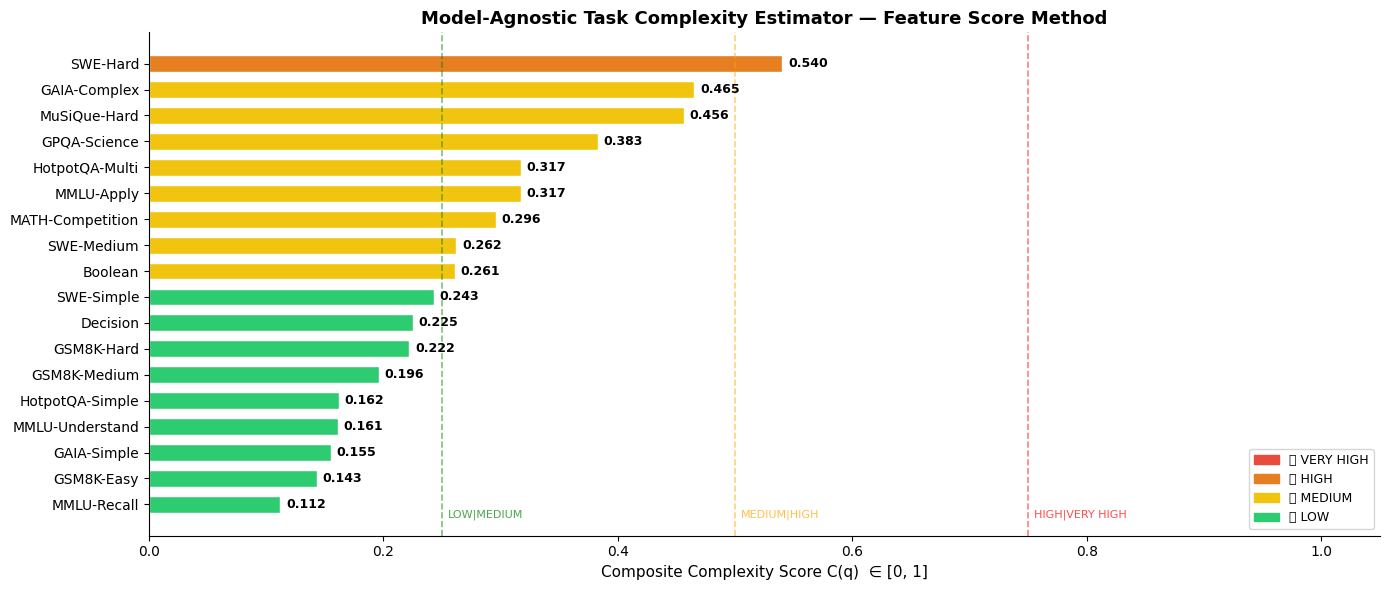

In [26]:
BAND_COLORS = {
    "🔴 VERY HIGH": "#e74c3c",
    "🟠 HIGH":      "#e67e22",
    "🟡 MEDIUM":    "#f1c40f",
    "🟢 LOW":       "#2ecc71",
}

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = [BAND_COLORS.get(b, "#95a5a6") for b in df["band"]]
bars = ax.barh(df["label"], df["C"], color=bar_colors, edgecolor="white", height=0.65)

for bar, val in zip(bars, df["C"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9, fontweight="bold")

# Threshold lines
for thresh, label_t, color_t in [(0.25,"LOW|MEDIUM","green"),(0.50,"MEDIUM|HIGH","orange"),(0.75,"HIGH|VERY HIGH","red")]:
    ax.axvline(thresh, linestyle="--", color=color_t, alpha=0.5, linewidth=1.2)
    ax.text(thresh+0.005, len(df)-0.5, label_t, color=color_t, fontsize=8, alpha=0.7)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in BAND_COLORS.items()]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.set_xlabel("Composite Complexity Score C(q)  ∈ [0, 1]", fontsize=11)
ax.set_title("Model-Agnostic Task Complexity Estimator — Feature Score Method", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.05)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/complexity_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Bar chart saved.")

## Cell 12 — Visualization 2: Radar / Dimension Breakdown

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/complexity_radar.png'

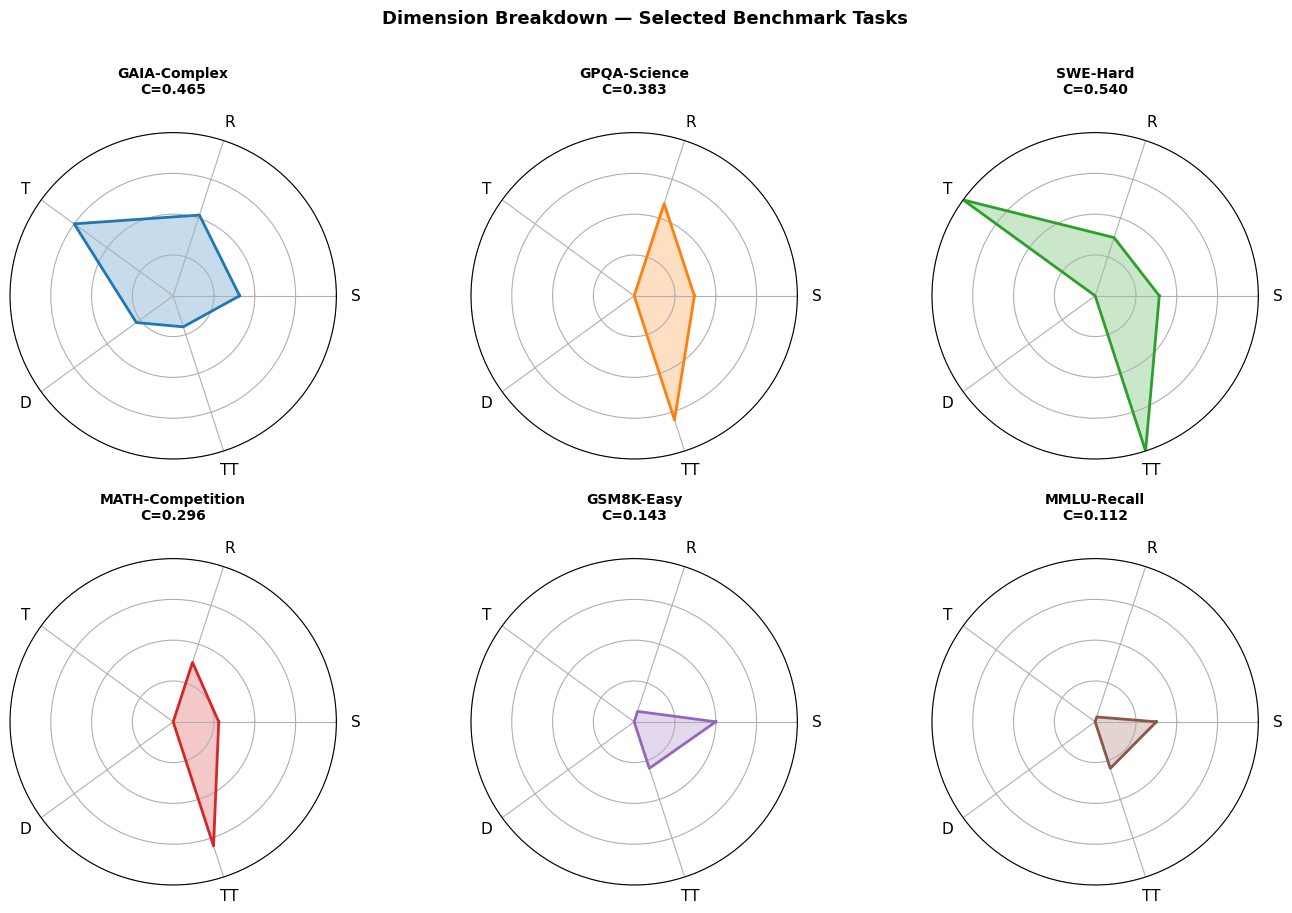

In [27]:
# Show radar plots for 6 representative tasks
RADAR_TASKS = ["GAIA-Complex","GPQA-Science","SWE-Hard",
               "MATH-Competition","GSM8K-Easy","MMLU-Recall"]

dims   = ["S","R","T","D","TT"]
n_dims = len(dims)
angles = np.linspace(0, 2*np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]   # close polygon

fig, axes = plt.subplots(2, 3, figsize=(14, 9), subplot_kw={"polar": True})
palette = plt.cm.tab10.colors

for ax, task_label, color in zip(axes.flat, RADAR_TASKS, palette):
    row = df[df["label"] == task_label]
    if row.empty:
        ax.set_visible(False)
        continue
    values = [float(row[d].values[0]) for d in dims]
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), dims, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["", "", "", ""])
    C_val = float(row["C"].values[0])
    ax.set_title(f"{task_label}\nC={C_val:.3f}", pad=15, fontsize=10, fontweight="bold")

fig.suptitle("Dimension Breakdown — Selected Benchmark Tasks", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/complexity_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Radar chart saved.")

## Cell 13 — Visualization 3: Heatmap — All Tasks × All Dimensions

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/complexity_heatmap.png'

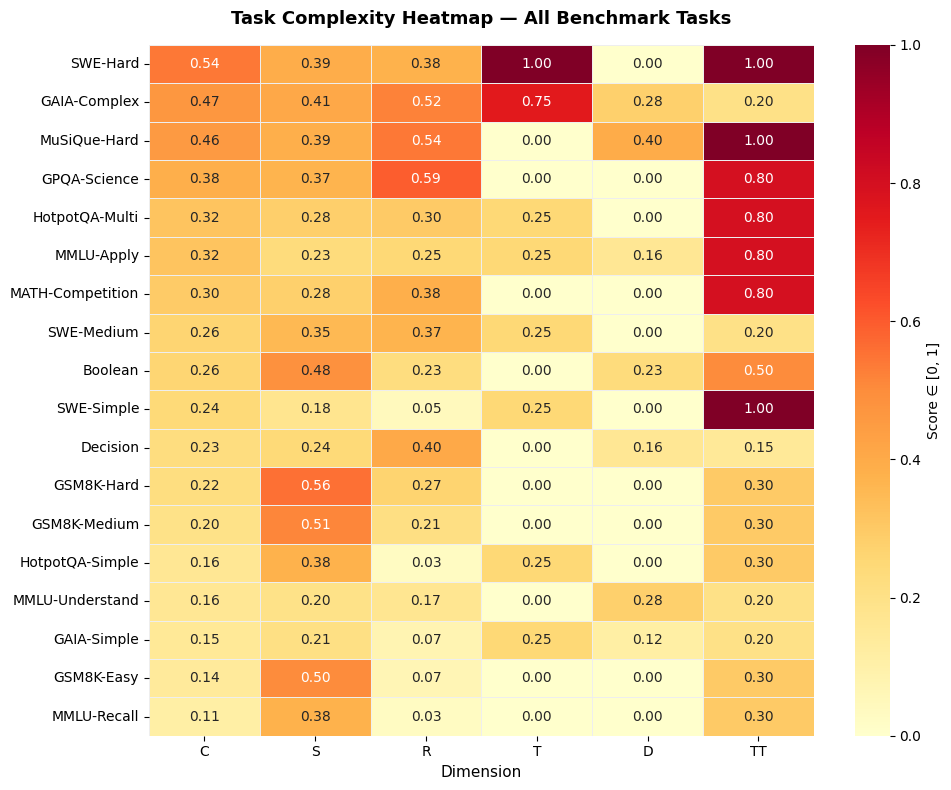

In [28]:
heat_data = df.set_index("label")[["C","S","R","T","D","TT"]]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heat_data.astype(float),
    annot=True, fmt=".2f", cmap="YlOrRd",
    linewidths=0.5, linecolor="#eeeeee",
    vmin=0, vmax=1, ax=ax,
    cbar_kws={"label": "Score ∈ [0, 1]"},
)
ax.set_title("Task Complexity Heatmap — All Benchmark Tasks", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Dimension", fontsize=11)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/complexity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Heatmap saved.")

## Cell 14 — Weight Sensitivity Analysis

The professor asked: *"how do you define the complexity scale?"*  
This cell shows how the composite score C(q) shifts under different weight regimes.

config        Default (R-dominant)  Reasoning-only  Tool-heavy (Agentic)  Uniform
task                                                                             
Boolean                      0.261           0.231                 0.190    0.289
GAIA-Complex                 0.196           0.178                 0.134    0.205
GPQA-Science                 0.112           0.052                 0.075    0.141
GSM8K-Medium                 0.465           0.487                 0.532    0.431
MMLU-Recall                  0.383           0.496                 0.265    0.353
SWE-Hard                     0.540           0.463                 0.633    0.554


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/complexity_sensitivity.png'

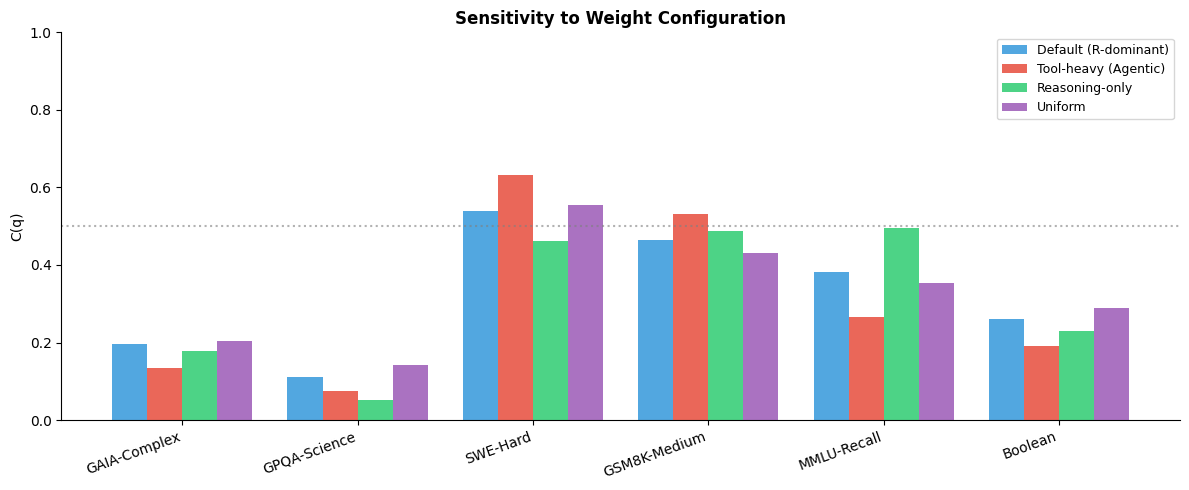

In [29]:
WEIGHT_CONFIGS = {
    "Default (R-dominant)": {"S": 0.15, "R": 0.35, "T": 0.20, "D": 0.15, "TT": 0.15},
    "Tool-heavy (Agentic)":  {"S": 0.10, "R": 0.25, "T": 0.40, "D": 0.15, "TT": 0.10},
    "Reasoning-only":        {"S": 0.00, "R": 0.70, "T": 0.10, "D": 0.10, "TT": 0.10},
    "Uniform":               {"S": 0.20, "R": 0.20, "T": 0.20, "D": 0.20, "TT": 0.20},
}

# Sample 6 representative tasks
sample_labels = ["GAIA-Complex","GPQA-Science","SWE-Hard","GSM8K-Medium","MMLU-Recall","Boolean"]
sample_queries = [q for l, q in BENCHMARK_TASKS if l in sample_labels]

sens_rows = []
for config_name, w in WEIGHT_CONFIGS.items():
    est = TaskComplexityEstimator(weights=w)
    for label, query in zip(sample_labels, sample_queries):
        result = est.score(query)
        sens_rows.append({"config": config_name, "task": label, "C": round(result.C, 3)})

sens_df = pd.DataFrame(sens_rows).pivot(index="task", columns="config", values="C")
print(sens_df.to_string())

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(sample_labels))
width = 0.2
colors_w = ["#3498db","#e74c3c","#2ecc71","#9b59b6"]
for i, (config_name, color_w) in enumerate(zip(WEIGHT_CONFIGS.keys(), colors_w)):
    vals = [sens_df.loc[l, config_name] for l in sample_labels]
    ax.bar(x + i*width, vals, width, label=config_name, color=color_w, alpha=0.85)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(sample_labels, rotation=20, ha="right")
ax.set_ylabel("C(q)")
ax.set_ylim(0, 1)
ax.set_title("Sensitivity to Weight Configuration", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.axhline(0.5, linestyle=":", color="gray", alpha=0.6)
sns.despine()
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/complexity_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sensitivity analysis saved.")

## Cell 15 — Single-Query Deep Dive (Interactive Use)

In [30]:
def deep_dive(query: str) -> None:
    """
    Pretty-print a full diagnostic breakdown for any query.
    Run this interactively to inspect a single task.
    """
    result = estimator.score(query)

    print("=" * 70)
    print(f"QUERY  : {query}")
    print("=" * 70)
    print(f"\n🎯  FINAL SCORE   C = {result.C:.4f}   {result.complexity_band}")
    print(f"\n  Weights used : S={estimator.weights['S']} R={estimator.weights['R']} "
          f"T={estimator.weights['T']} D={estimator.weights['D']} TT={estimator.weights['TT']}")

    print("\n" + "─" * 70)
    print("L1 SURFACE FEATURES   S = {:.4f}".format(result.S))
    for k, v in result.raw_S.items():
        print(f"   {k:25s}: {v}")

    print("\n" + "─" * 70)
    print("L2 REASONING DEPTH    R = {:.4f}".format(result.R))
    for k, v in result.raw_R.items():
        print(f"   {k:25s}: {v}")

    print("\n" + "─" * 70)
    print("L3 TOOL DEPENDENCY    T = {:.4f}".format(result.T))
    print(f"   matched_categories  : {result.raw_T['matched_categories']}")
    print(f"   category_count      : {result.raw_T['category_count']}")

    print("\n" + "─" * 70)
    print("L4 DOMAIN SKILLS      D = {:.4f}".format(result.D))
    print(f"   matched_domains     : {result.raw_D['matched_domains']}")
    print(f"   temporal_signals    : {result.raw_D['temporal_signals']}")

    print("\n" + "─" * 70)
    print("L5 TASK TYPE         TT = {:.4f}".format(result.TT))
    print(f"   primary_type        : {result.raw_TT['primary_type']}")
    print(f"   all_matched         : {[m['type'] for m in result.raw_TT['all_matched']]}")
    print("=" * 70)


# ── Example ──────────────────────────────────────────────────────────────────
deep_dive(
    "Design and implement a multi-agent system that searches arxiv for recent "
    "RLHF papers, extracts key contributions, stores them in a SQLite database, "
    "and generates a LaTeX survey paper with a bibliography."
)

QUERY  : Design and implement a multi-agent system that searches arxiv for recent RLHF papers, extracts key contributions, stores them in a SQLite database, and generates a LaTeX survey paper with a bibliography.

🎯  FINAL SCORE   C = 0.5320   🟠 HIGH

  Weights used : S=0.15 R=0.35 T=0.2 D=0.15 TT=0.15

──────────────────────────────────────────────────────────────────────
L1 SURFACE FEATURES   S = 0.3717
   token_count              : 32
   ner_density              : 0.0811
   mattr                    : 0.925

──────────────────────────────────────────────────────────────────────
L2 REASONING DEPTH    R = 0.5963
   bloom_level              : 6
   syntactic_depth          : 8.0
   multi_hop                : 1
   negation_count           : 0
   conditional_count        : 0
   modifier_density         : 0.1351

──────────────────────────────────────────────────────────────────────
L3 TOOL DEPENDENCY    T = 0.5000
   matched_categories  : ['code_execution', 'database']
   category_count   

## Cell 16 — Export Results to CSV

In [ ]:
out_path = "/mnt/user-data/outputs/task_complexity_results.csv"
df.to_csv(out_path, index=False)
print(f"✅ Results exported to: {out_path}")
display(df.head(5))

## Cell 17 — Summary Statistics & Band Distribution

In [31]:
print("\n━━━ Summary Statistics ━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(df[["C","S","R","T","D","TT"]].describe().round(3).to_string())

print("\n━━━ Complexity Band Distribution ━━━━━━━━━━━━━━━━━━")
band_counts = df["band"].value_counts()
print(band_counts.to_string())

print("\n━━━ Top-5 Most Complex Tasks ━━━━━━━━━━━━━━━━━━━━━━")
print(df.head(5)[["label","C","band","task_type","bloom_level"]].to_string(index=False))

print("\n━━━ Top-5 Least Complex Tasks ━━━━━━━━━━━━━━━━━━━━━")
print(df.tail(5)[["label","C","band","task_type","bloom_level"]].to_string(index=False))


━━━ Summary Statistics ━━━━━━━━━━━━━━━━━━━━━━━━━━━━
           C      S      R      T      D     TT
count 18.000 18.000 18.000 18.000 18.000 18.000
mean   0.273  0.352  0.270  0.181  0.091  0.508
std    0.122  0.115  0.180  0.282  0.130  0.325
min    0.112  0.179  0.031  0.000  0.000  0.150
25%    0.170  0.254  0.099  0.000  0.000  0.225
50%    0.252  0.372  0.259  0.000  0.000  0.300
75%    0.317  0.403  0.381  0.250  0.163  0.800
max    0.540  0.558  0.594  1.000  0.396  1.000

━━━ Complexity Band Distribution ━━━━━━━━━━━━━━━━━━
band
🟢 LOW       9
🟡 MEDIUM    8
🟠 HIGH      1

━━━ Top-5 Most Complex Tasks ━━━━━━━━━━━━━━━━━━━━━━
         label     C     band  task_type  bloom_level
      SWE-Hard 0.540   🟠 HIGH generative            6
  GAIA-Complex 0.465 🟡 MEDIUM    unknown            5
  MuSiQue-Hard 0.456 🟡 MEDIUM generative            6
  GPQA-Science 0.383 🟡 MEDIUM  reasoning            6
HotpotQA-Multi 0.317 🟡 MEDIUM  reasoning            4

━━━ Top-5 Least Complex Tasks ━━━━━━━

---
## Appendix — Method Summary

| Component | Technique | Library | LLM Required? |
|-----------|-----------|---------|---------------|
| L1 Surface (S) | Token count, MATTR, NER density | spaCy | ❌ No |
| L2 Reasoning (R) | Bloom verb regex, dep-tree depth, negation/conditionals | spaCy | ❌ No |
| L3 Tool (T) | Keyword category scan | regex | ❌ No |
| L4 Domain (D) | Domain lexicon + temporal pattern | regex | ❌ No |
| L5 Task Type (TT) | Structural output type classifier | regex | ❌ No |
| Composite C(q) | Weighted sum | numpy | ❌ No |

### Why these techniques?

- **MATTR** is preferred over raw TTR because it is length-independent, making it fair across short and long queries alike.
- **Bloom's Taxonomy** provides a validated, research-backed 6-level cognitive hierarchy grounded in decades of educational psychology.
- **Dependency tree depth** is a well-established structural proxy for syntactic complexity used in readability and NLP difficulty research.
- **Weighted composite** allows domain-specific tuning — e.g. set `T` weight higher for routing in agentic systems.
- **Zero LLM calls** means the estimator is fast, deterministic, and serves as a true baseline for comparison against VAE-based approaches.

### Comparison Baseline
This method (Method 1: Feature Score) is designed to be the **model-agnostic baseline** for comparison against:
- **Method 2:** VAE-based embedding complexity (from the referenced paper)  
- **Method 3:** Model-internal entropy / uncertainty estimation  
- **Method 4:** Society-of-Thoughts internal reasoning complexity